In [ ]:
# Controlling cpu usage
import os
os.environ["NUMBA_NUM_THREADS"] = "6"
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
import scanpy as sc
import scvi
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# Use the raw data for evaluation
brain_vascular = sc.read_h5ad("../brain_vascular.h5ad")
adata = brain_vascular.raw.to_adata()

# Adding mitochondrial gene annotation
adata.var["mt"] = adata.var["feature_name"].str.upper().str.startswith("MT-")
# Calculating QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

adata_qc = adata[
    (adata.obs["n_genes_by_counts"] > 300) &
    (adata.obs["n_genes_by_counts"] < 8000) &
    (adata.obs["total_counts"] < 55000) &
    (adata.obs["pct_counts_mt"] < 15),
    :
].copy()

In [5]:
# HVGs selection
sc.pp.highly_variable_genes(adata_qc, n_top_genes=2000, flavor="seurat_v3")
adata_qc = adata_qc[:, adata_qc.var["highly_variable"]].copy()

In [11]:
# Train/Test split
label_key = "author_cell_type"
adata_qc.obs[label_key] = adata_qc.obs[label_key].astype("category")

train_idx, test_idx = train_test_split(
    np.arange(adata_qc.n_obs),
    test_size=0.2,
    stratify=adata_qc.obs[label_key],
    random_state=42
)

In [14]:
# Marking test set labels as "Unknown"
adata_qc.obs["scanvi_label"] = adata_qc.obs[label_key].copy()

if "Unknown" not in adata_qc.obs["scanvi_label"].cat.categories:
    adata_qc.obs["scanvi_label"] = adata_qc.obs["scanvi_label"].cat.add_categories(["Unknown"])
adata_qc.obs.iloc[test_idx, adata_qc.obs.columns.get_loc("scanvi_label")] = "Unknown"

adata_qc.obs["scanvi_label"] = adata_qc.obs["scanvi_label"].astype("category")

In [17]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [18]:
# Setting up the AnnData object for scVI
scvi.model.SCVI.setup_anndata(
    adata_qc,
    labels_key="scanvi_label"
)

In [19]:
# Training the scVI model
scvi_model = scvi.model.SCVI(
    adata_qc,
    n_latent=30,
    n_layers=2,
    n_hidden=128
)

scvi_model.train(
    max_epochs=100,
    early_stopping=True
)

/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data/slurm/huangjr/envs/scInterBrain/lib/python3.11 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data/slurm/huangjr/envs/scInterBrain

Epoch 100/100: 100%|██████████| 100/100 [10:44<00:00,  6.73s/it, v_num=1, train_loss=466]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [10:44<00:00,  6.45s/it, v_num=1, train_loss=466]


In [20]:
# Convert scVI to scVANVI
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    unlabeled_category="Unknown"
)

scanvi_model.train(
    max_epochs=50,
    early_stopping=True
)

INFO     Training for 50 epochs.                                                                                   


/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data/slurm/huangjr/envs/scInterBrain/lib/python3.11 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/data/slurm/huangjr/envs/scInterBrain/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data/slurm/huangjr/envs/scInterBrain

Epoch 50/50: 100%|██████████| 50/50 [13:27<00:00, 15.76s/it, v_num=1, train_loss=457]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [13:27<00:00, 16.15s/it, v_num=1, train_loss=457]


In [22]:
# Predict cell types
adata_qc.obs["scanvi_pred"] = scanvi_model.predict(adata_qc)
y_test = adata_qc.obs.iloc[test_idx][label_key]
y_pred = adata_qc.obs.iloc[test_idx]["scanvi_pred"]

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


In [24]:
# Prediction evalutation
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Macro precision:", macro_precision)
print("Macro recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Accuracy: 0.9662601626016261
Macro precision: 0.9693501355889904
Macro recall: 0.972142076451773
Macro F1: 0.9706670420017645
Weighted F1: 0.9661798931950328


In [25]:
# Classification report
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
Arterial,0.944444,0.960921,0.952612,1433.00000
Astrocyte,0.968531,0.992832,0.980531,279.00000
Capillary,0.900065,0.901821,0.900942,1538.00000
Excitatory_Neuron,0.993220,0.984874,0.989030,595.00000
Inhibitory_Neuron,0.981538,0.993769,0.987616,321.00000
Meningeal_Fibroblast,0.993927,0.987928,0.990918,497.00000
Microglia,0.991878,0.991375,0.991626,1971.00000
Oligodendrocyte,0.997378,0.987879,0.992605,1155.00000
Oligodendrocyte_Precursor_Cell,1.000000,1.000000,1.000000,114.00000
Pericyte,0.972936,0.974255,0.973595,738.00000


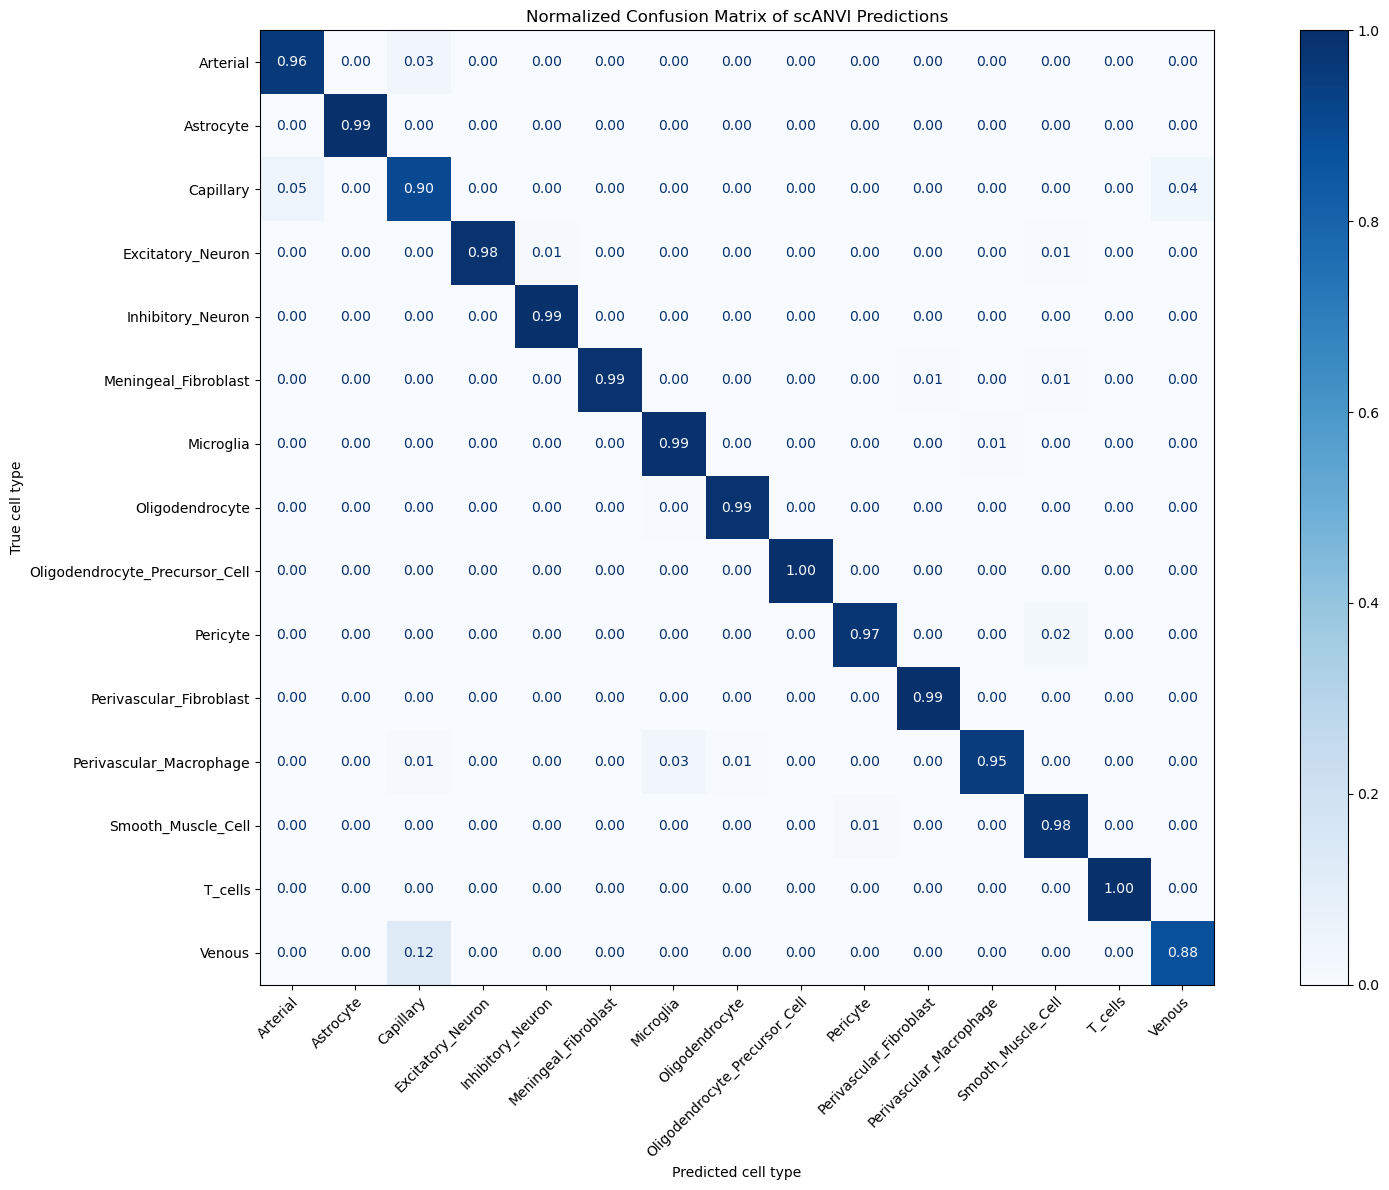

In [ ]:
# Confusion matrix
class_names = sorted(pd.Series(y_test).unique())

# Normalized confusion matrix
cm_norm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(18, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

ax.set_title("Normalized Confusion Matrix of scANVI Predictions")
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("True cell type")

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_rotation_mode("anchor")

plt.tight_layout()
plt.savefig("../metrics/scANVI_conf_matrix.png", dpi=300, bbox_inches="tight")
plt.show()